<style>
  body {
    margin: 0;
    padding: 0;
    font-family: Arial, sans-serif;
  }

  /* Linha das logos usando table layout */
  .cover-header {
    display: table;
    width: 100%;
    margin-top: 20px;
    table-layout: fixed;
  }

  .cover-header .left{
    display: table-cell;
    width: 20%;
    vertical-align: middle;
    text-align: center;
  }
  .cover-header .right {
    display: table-cell;
    width: 30%;
    vertical-align: middle;
    text-align: center;
  }

  .cover-header .center {
    display: table-cell;
    width: 50%;
    text-align: center;
    vertical-align: middle;
  }

  .cover-header img {
    max-height: 55px;
    width: auto;
    display: inline-block;
  }

  /* Texto institucional embaixo das logos */
  .cover-center {
    text-align: center;
    margin-top: 20px;
    vertical-align: middle;
  }

  .cover-center p {
    text-align: center;
    vertical-align: middle;
    margin: 0;
    font-weight: 700;
    line-height: 1.4;
    font-size: 16px;
  }

  /* Título e autor */
  .cover-title {
    margin-top: 120px;
    text-align: center;
  }

  .cover-title h1 {
    font-size: 28px;
    margin-bottom: 60px;
  }

  .cover-title .author {
    font-size: 18px;
    margin-top: 160px; /* nome bem mais abaixo */
  }

  /* Rodapé fixo */
  .cover-footer {
    position: absolute;
    bottom: 30px;
    left: 0;
    width: 100%;
    text-align: center;
    font-size: 14px;
  }

  .cover-footer {
  position: absolute;
  bottom: 30px;
  left: 0;
  width: 100%;
  text-align: center;
  font-size: 14px;
}

</style>

<div class="cover-header">
  <div class="left">
    <img src="Imagens/logo_virtus2.png" alt="Logo VIRTUS">
  </div>
  <div class = "center"></div>
  <div class="right">
    <img src="Imagens/logo_ufcg.png" alt="Logo UFCG">
  </div>
</div>

<div class="cover-center">
  <p>
    UNIVERSIDADE FEDERAL DE CAMPINA GRANDE<br>
    CENTRO DE CIÊNCIAS E TECNOLOGIA<br>
    CENTRO DE ENGENHARIA ELÉTRICA E INFORMÁTICA<br>
    CENTRO DE COMPETÊNCIAS EMBRAPII VIRTUS-CC
  </p>
</div>

<div class="cover-title">
  <h1>Conversão de Taxa de Amostragem</h1>
  <p class="author">Jezrael Pereira Filgueiras</p>
</div>

<div class="cover-footer">
  Campina Grande, 12 de Março de 2026
</div>

<div style="page-break-after: always;"></div>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import decimate
import math
import sys
sys.path.append('./pds_utils')
import pds_utils as pds

np.random.seed(42)
plt.style.use('seaborn-v0_8')

In [105]:
def decimate_fft(x, N):
    """ Decimate a signal by a factor of N using FFT.
    Parameters
    ----------
    x : array_like
        Input signal.
    N : int
        Decimation factor.
    Returns
    -------
    y : ndarray
        Decimated signal.
    """

    N_out = math.ceil(len(x) / N)
    X = np.fft.fft(x, len(x))
    
    print(f"Decimation factor: {N}, Output length: {N_out}")
    X =np.fft.fftshift(X)

    f_0 = len(x)//2
    idx_start = int(f_0 - N_out//2)

    X_decimate = X[idx_start:idx_start+N_out]
    print(f"Decimated FFT length: {len(X_decimate)}")
    X_decimate = np.fft.ifftshift(X_decimate)
    x_decimate = np.fft.ifft(X_decimate)

    return x_decimate/np.max(np.abs(x_decimate))

    


Decimation factor: 4, Output length: 27
Decimated FFT length: 27
27 27


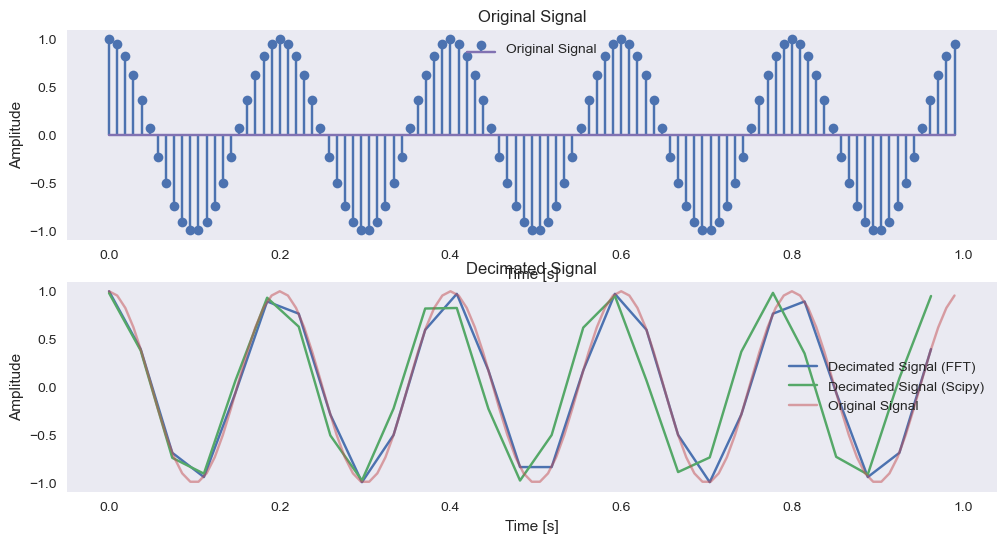

In [107]:
n = np.linspace(0, 1, 105, endpoint=False)
x_n = np.cos(2 * np.pi * 5 * n) #+ 0.5 * np.cos(2 * np.pi * 10 * n)
x_decimate = decimate_fft(x_n, 4)
x_decimate_scipy = decimate(x_n, 4)

print(len(x_decimate), len(x_decimate_scipy))

plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.stem(n, x_n, label='Original Signal')
plt.title('Original Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
n_decimate = np.linspace(0, 1, len(x_decimate), endpoint=False)
n_decimate_scipy = np.linspace(0, 1, len(x_decimate_scipy), endpoint=False)
plt.plot(n_decimate, x_decimate, label='Decimated Signal (FFT)')
plt.plot(n_decimate_scipy, x_decimate_scipy, label='Decimated Signal (Scipy)')
plt.plot(n, x_n, label='Original Signal', alpha=0.5)
plt.title('Decimated Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.grid()
plt.legend()